Dataset saved successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5000 non-null   int64  
 1   income                 5000 non-null   int64  
 2   employment_years       5000 non-null   int64  
 3   debt                   5000 non-null   int64  
 4   monthly_expenses       5000 non-null   int64  
 5   credit_utilization     5000 non-null   float64
 6   late_payments_12m      5000 non-null   int64  
 7   loan_count             5000 non-null   int64  
 8   savings                5000 non-null   int64  
 9   payment_history_score  5000 non-null   int64  
 10  high_risk              5000 non-null   int64  
dtypes: float64(1), int64(10)
memory usage: 429.8 KB


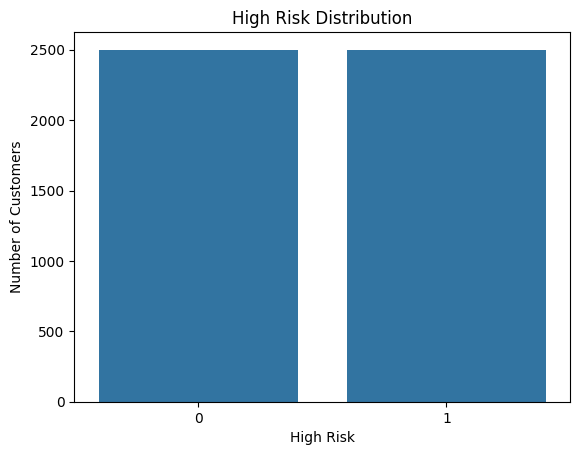

Training samples: 4000
Testing samples: 1000
Logistic Regression
--------------------
Precision: 0.980276134122288
Recall: 0.994
F1 Score: 0.9870903674280039
ROC-AUC: 0.999676
Decision Tree
-------------
Precision: 0.8907922912205567
Recall: 0.832
F1 Score: 0.860392967942089
ROC-AUC: 0.9327559999999999
Random Forest
-------------
Precision: 0.9317269076305221
Recall: 0.928
F1 Score: 0.9298597194388778
ROC-AUC: 0.98268
Best Model: Logistic Regression


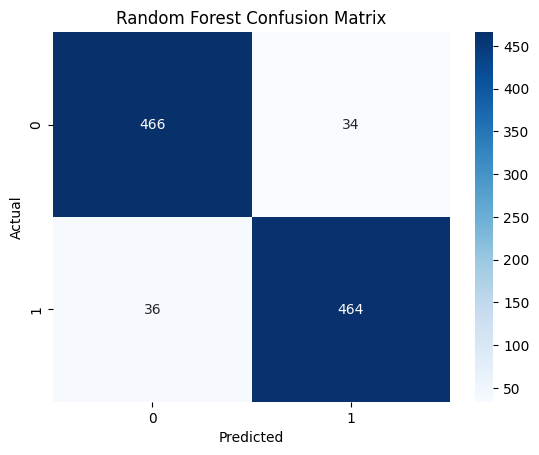

              precision    recall  f1-score   support

  Lower Risk       0.93      0.93      0.93       500
 Higher Risk       0.93      0.93      0.93       500

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



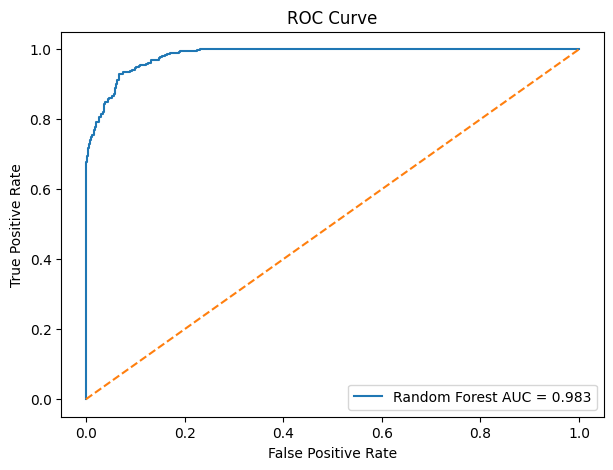

late_payments_12m        0.334837
credit_utilization       0.198772
payment_history_score    0.155602
debt_to_income           0.076464
savings_to_debt          0.070625
debt                     0.048824
savings                  0.034978
income                   0.029959
expense_to_income        0.016881
monthly_expenses         0.011640
age                      0.008220
employment_years         0.008138
loan_count               0.005059
dtype: float64


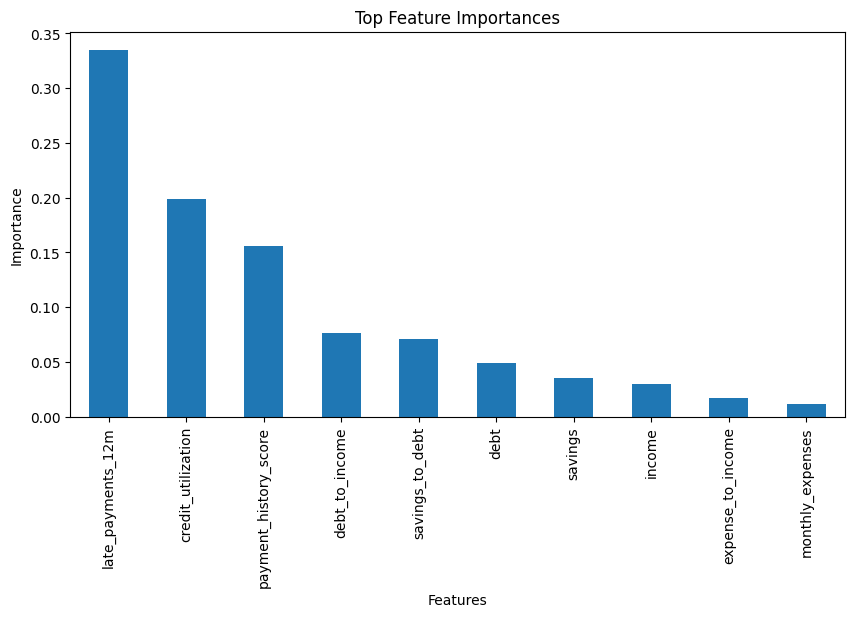

Model saved successfully!
Predicted Risk: Lower Risk
Estimated higher-risk probability: 3.28%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
#Untitled0.ipynb
#Credit_Scoring_ML_Project.ipynb
!pip install pandas numpy scikit-learn matplotlib seaborn joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

np.random.seed(42)

n = 5000

data = pd.DataFrame({
    "age": np.random.randint(21, 65, n),
    "income": np.random.randint(20000, 120000, n),
    "employment_years": np.random.randint(0, 30, n),
    "debt": np.random.randint(1000, 80000, n),
    "monthly_expenses": np.random.randint(500, 8000, n),
    "credit_utilization": np.round(np.random.uniform(0.05, 0.95, n), 2),
    "late_payments_12m": np.random.randint(0, 8, n),
    "loan_count": np.random.randint(0, 8, n),
    "savings": np.random.randint(1000, 100000, n),
    "payment_history_score": np.random.randint(40, 100, n)
})

data.head()

#0 → Lower risk
#1 → Higher risk

risk_score = (
    2.5 * data["credit_utilization"]
    + 0.35 * data["late_payments_12m"]
    + 0.00002 * data["debt"]
    - 0.00001 * data["income"]
    - 0.00001 * data["savings"]
    - 0.03 * data["payment_history_score"]
)

threshold = risk_score.median()

data["high_risk"] = (risk_score > threshold).astype(int)

data.head()

data.to_csv("credit_data.csv", index=False)

print("Dataset saved successfully!")

data.shape


data.columns

data.info()

data.describe()

data.isnull().sum()

data["high_risk"].value_counts()

sns.countplot(x="high_risk", data=data)
plt.title("High Risk Distribution")
plt.xlabel("High Risk")
plt.ylabel("Number of Customers")
plt.show()

data["debt_to_income"] = data["debt"] / (data["income"] + 1)

monthly_income = data["income"] / 12

data["expense_to_income"] = (
    data["monthly_expenses"] / (monthly_income + 1)
)

data["savings_to_debt"] = (
    data["savings"] / (data["debt"] + 1)
)

data.head()

X = data.drop("high_risk", axis=1)
y = data["high_risk"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("--------------------")

print("Precision:",
      precision_score(y_test, logistic_pred))

print("Recall:",
      recall_score(y_test, logistic_pred))

print("F1 Score:",
      f1_score(y_test, logistic_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, logistic_prob))
decision_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ))
])
decision_tree.fit(X_train, y_train)
tree_pred = decision_tree.predict(X_test)

tree_prob = decision_tree.predict_proba(X_test)[:, 1]
print("Decision Tree")
print("-------------")

print("Precision:",
      precision_score(y_test, tree_pred))

print("Recall:",
      recall_score(y_test, tree_pred))

print("F1 Score:",
      f1_score(y_test, tree_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, tree_prob))
random_forest = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42
    ))
])
random_forest.fit(X_train, y_train)
rf_pred = random_forest.predict(X_test)

rf_prob = random_forest.predict_proba(X_test)[:, 1]
print("Random Forest")
print("-------------")

print("Precision:",
      precision_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("F1 Score:",
      f1_score(y_test, rf_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, rf_prob))
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, tree_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, tree_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, tree_pred),
        f1_score(y_test, rf_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, tree_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

results
best_model_name = results.loc[
    results["ROC-AUC"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=[
            "Lower Risk",
            "Higher Risk"
        ]
    )
)
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_prob
)

auc_score = roc_auc_score(
    y_test,
    rf_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
rf_model = random_forest.named_steps["model"]

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

importance.head(10).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

joblib.dump(
    random_forest,
    "credit_risk_model.joblib"
)

print("Model saved successfully!")

new_customer = pd.DataFrame({
    "age": [30],
    "income": [50000],
    "employment_years": [5],
    "debt": [15000],
    "monthly_expenses": [2500],
    "credit_utilization": [0.30],
    "late_payments_12m": [1],
    "loan_count": [2],
    "savings": [20000],
    "payment_history_score": [85]
})


new_customer["debt_to_income"] = (
    new_customer["debt"] /
    (new_customer["income"] + 1)
)

monthly_income = new_customer["income"] / 12

new_customer["expense_to_income"] = (
    new_customer["monthly_expenses"] /
    (monthly_income + 1)
)

new_customer["savings_to_debt"] = (
    new_customer["savings"] /
    (new_customer["debt"] + 1)
)

prediction = random_forest.predict(new_customer)

probability = random_forest.predict_proba(
    new_customer
)[0][1]

if prediction[0] == 1:
    print("Predicted Risk: Higher Risk")
else:
    print("Predicted Risk: Lower Risk")

print(
    f"Estimated higher-risk probability: {probability:.2%}"
)

from google.colab import files

files.download("credit_data.csv")

files.download("credit_risk_model.joblib")







